In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.linalg import cholesky # computes upper triangle by default, matches paper
import random
from mpl_toolkits.mplot3d import Axes3D
from embeddingVisualization import plotSPDEmbedding

In [3]:
n = 19
def random_spd_matrix(n):
    A = np.random.rand(n, n)
    return np.dot(A, A.transpose())

In [4]:
wavelet_manifold_output = {
    'delta': torch.tensor([
        random_spd_matrix(n) for i in range(11)
    ]).repeat(4, 1, 1),
    'theta': torch.tensor([
        random_spd_matrix(n) for i in range(11)
    ]).repeat(4, 1, 1),
    'alpha': torch.tensor([
        random_spd_matrix(n) for i in range(11)
    ]).repeat(4, 1, 1),
    'beta': torch.tensor([
        random_spd_matrix(n) for i in range(11)
    ]).repeat(4, 1, 1),
    'gamma': torch.tensor([
        random_spd_matrix(n) for i in range(11)
    ]).repeat(4, 1, 1),
}

combined_manifold_output = torch.tensor([random_spd_matrix(n) for i in range(11)])
combined_manifold_output = combined_manifold_output.repeat(4, 1, 1)
combined_manifold_output_masked = torch.tensor([random_spd_matrix(n) for i in range(11)])
combined_manifold_output_masked = combined_manifold_output_masked.repeat(4, 1, 1)
subject_names = ['sub1', 'sub2', 'sub3', 'sub4']

# Slow method but don't care since this is just testing
for band, v in wavelet_manifold_output.items():
    print(band, v.shape)
print(combined_manifold_output.shape)
print(combined_manifold_output_masked.shape)

delta torch.Size([44, 19, 19])
theta torch.Size([44, 19, 19])
alpha torch.Size([44, 19, 19])
beta torch.Size([44, 19, 19])
gamma torch.Size([44, 19, 19])
torch.Size([44, 19, 19])
torch.Size([44, 19, 19])


/tmp/ipykernel_1748708/3125598331.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  'delta': torch.tensor([


B: 44 N: 19 num_patches: 11 num_rows: 4 num_cols: 11


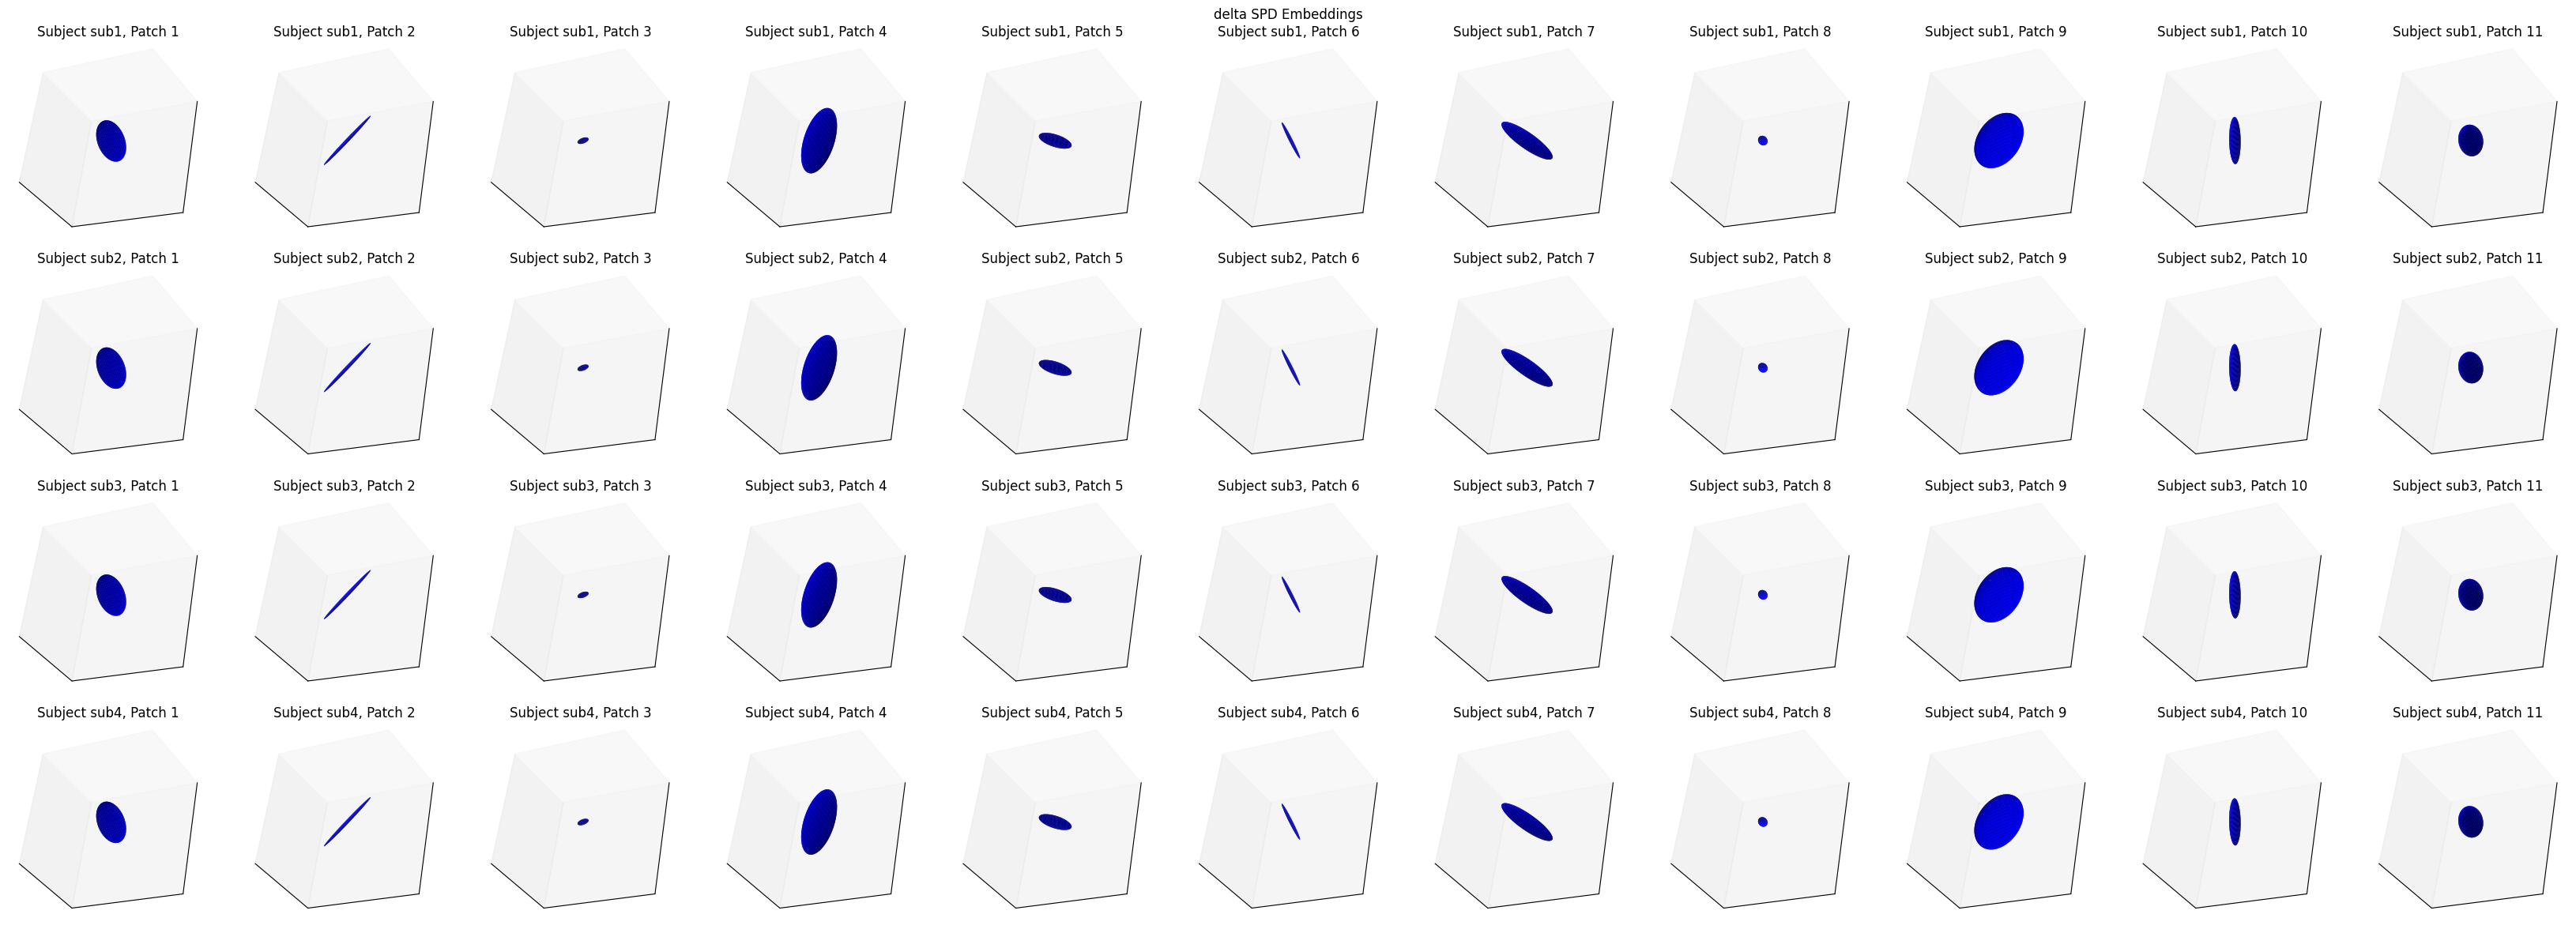

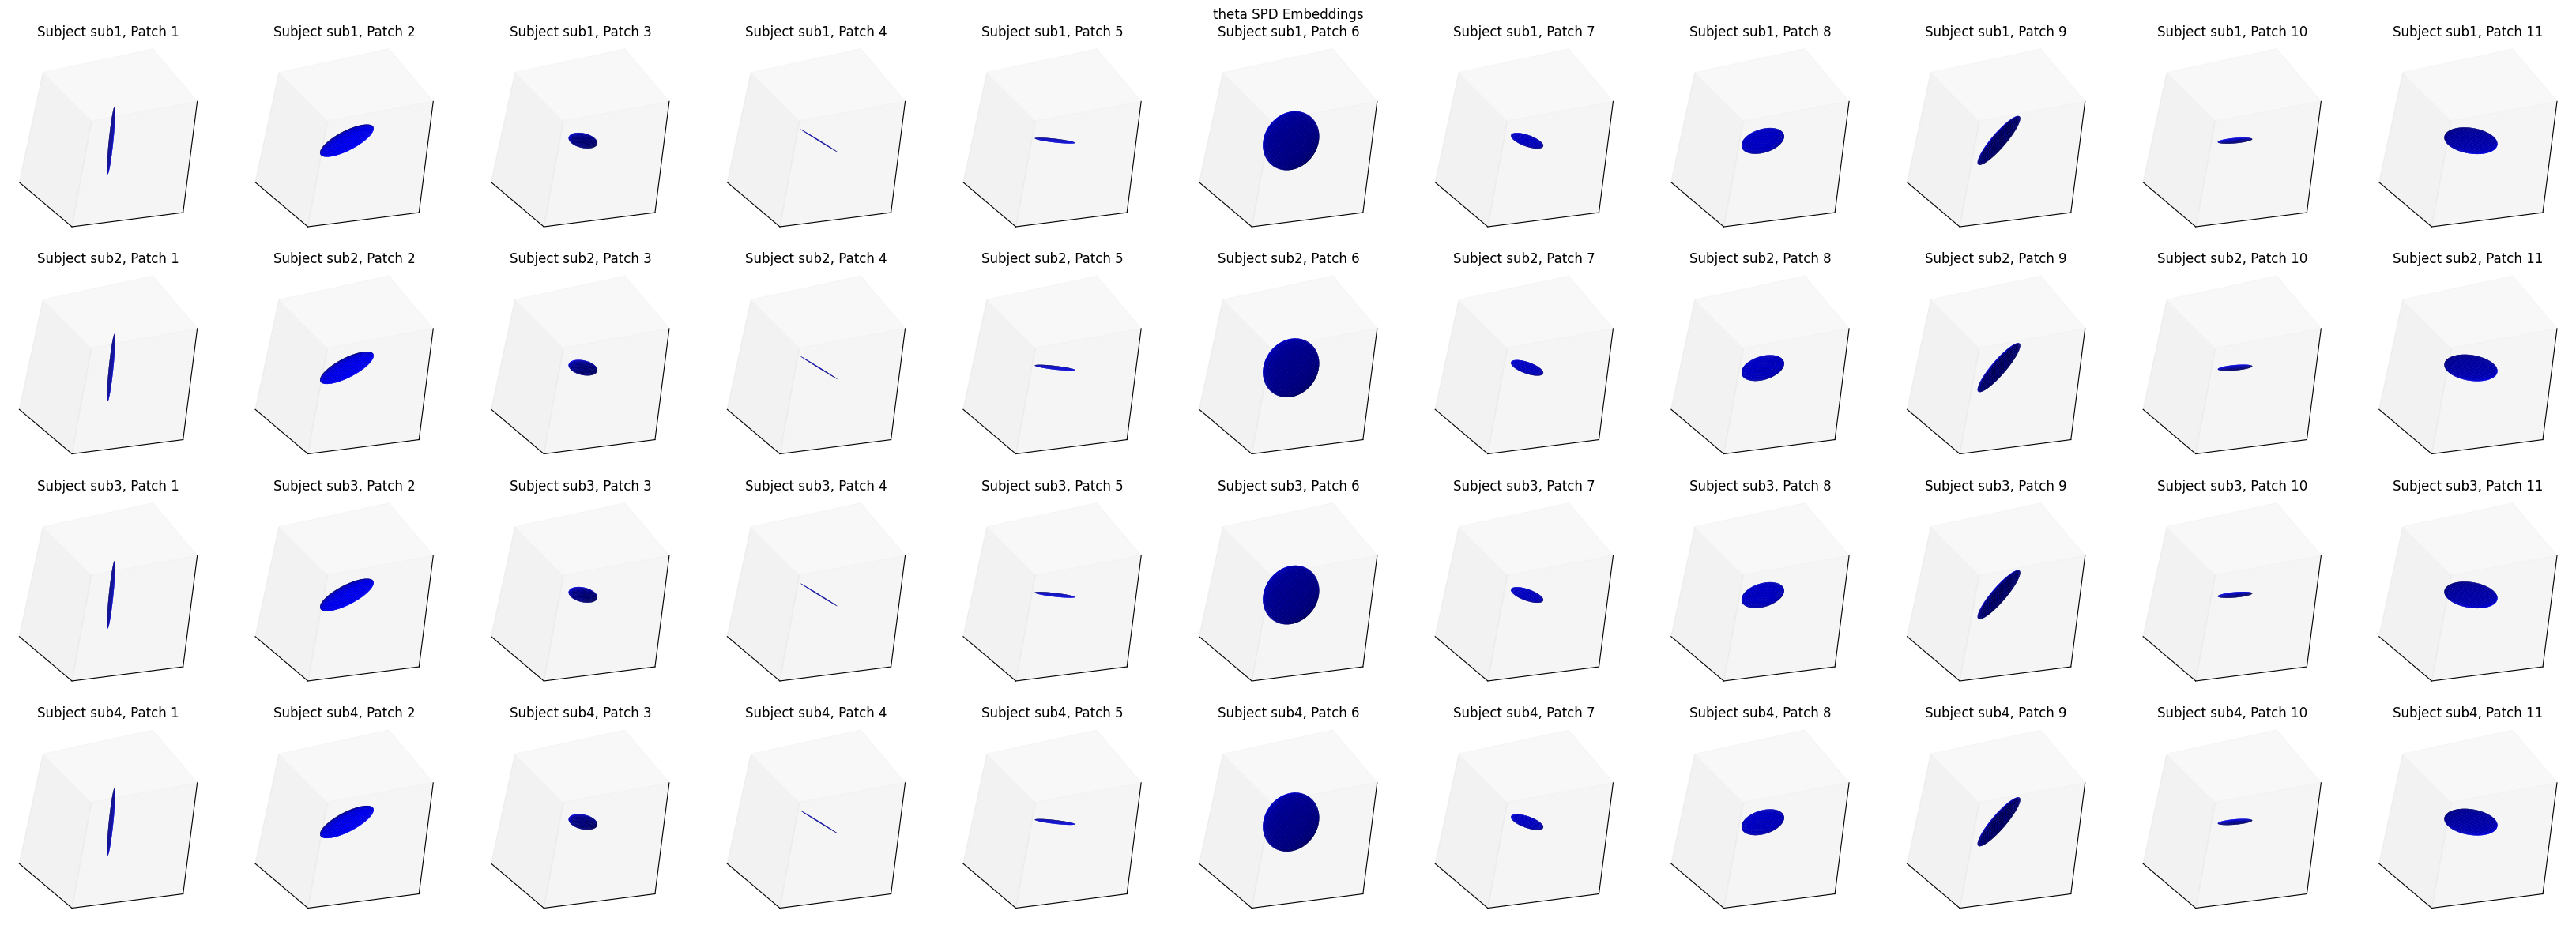

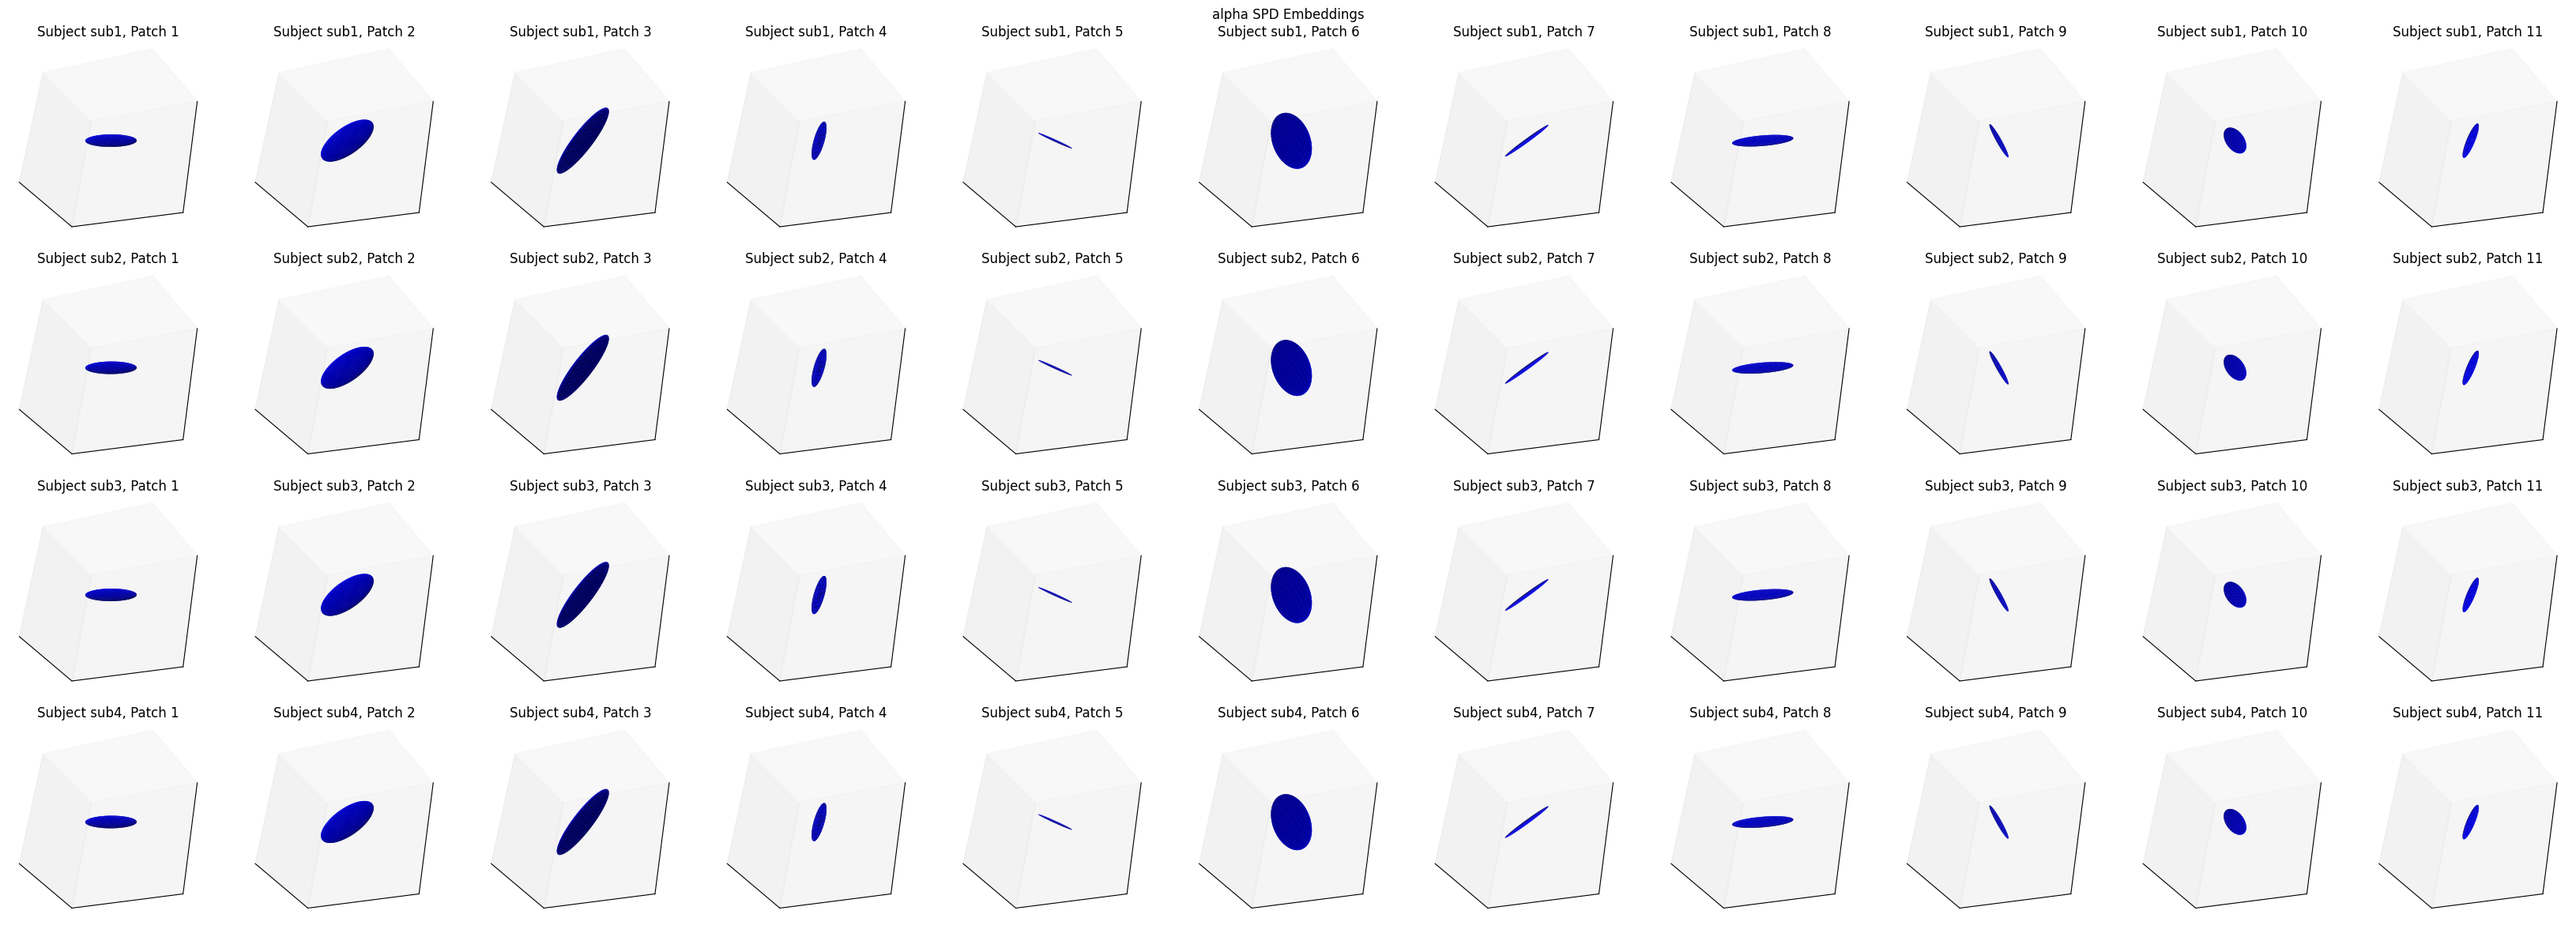

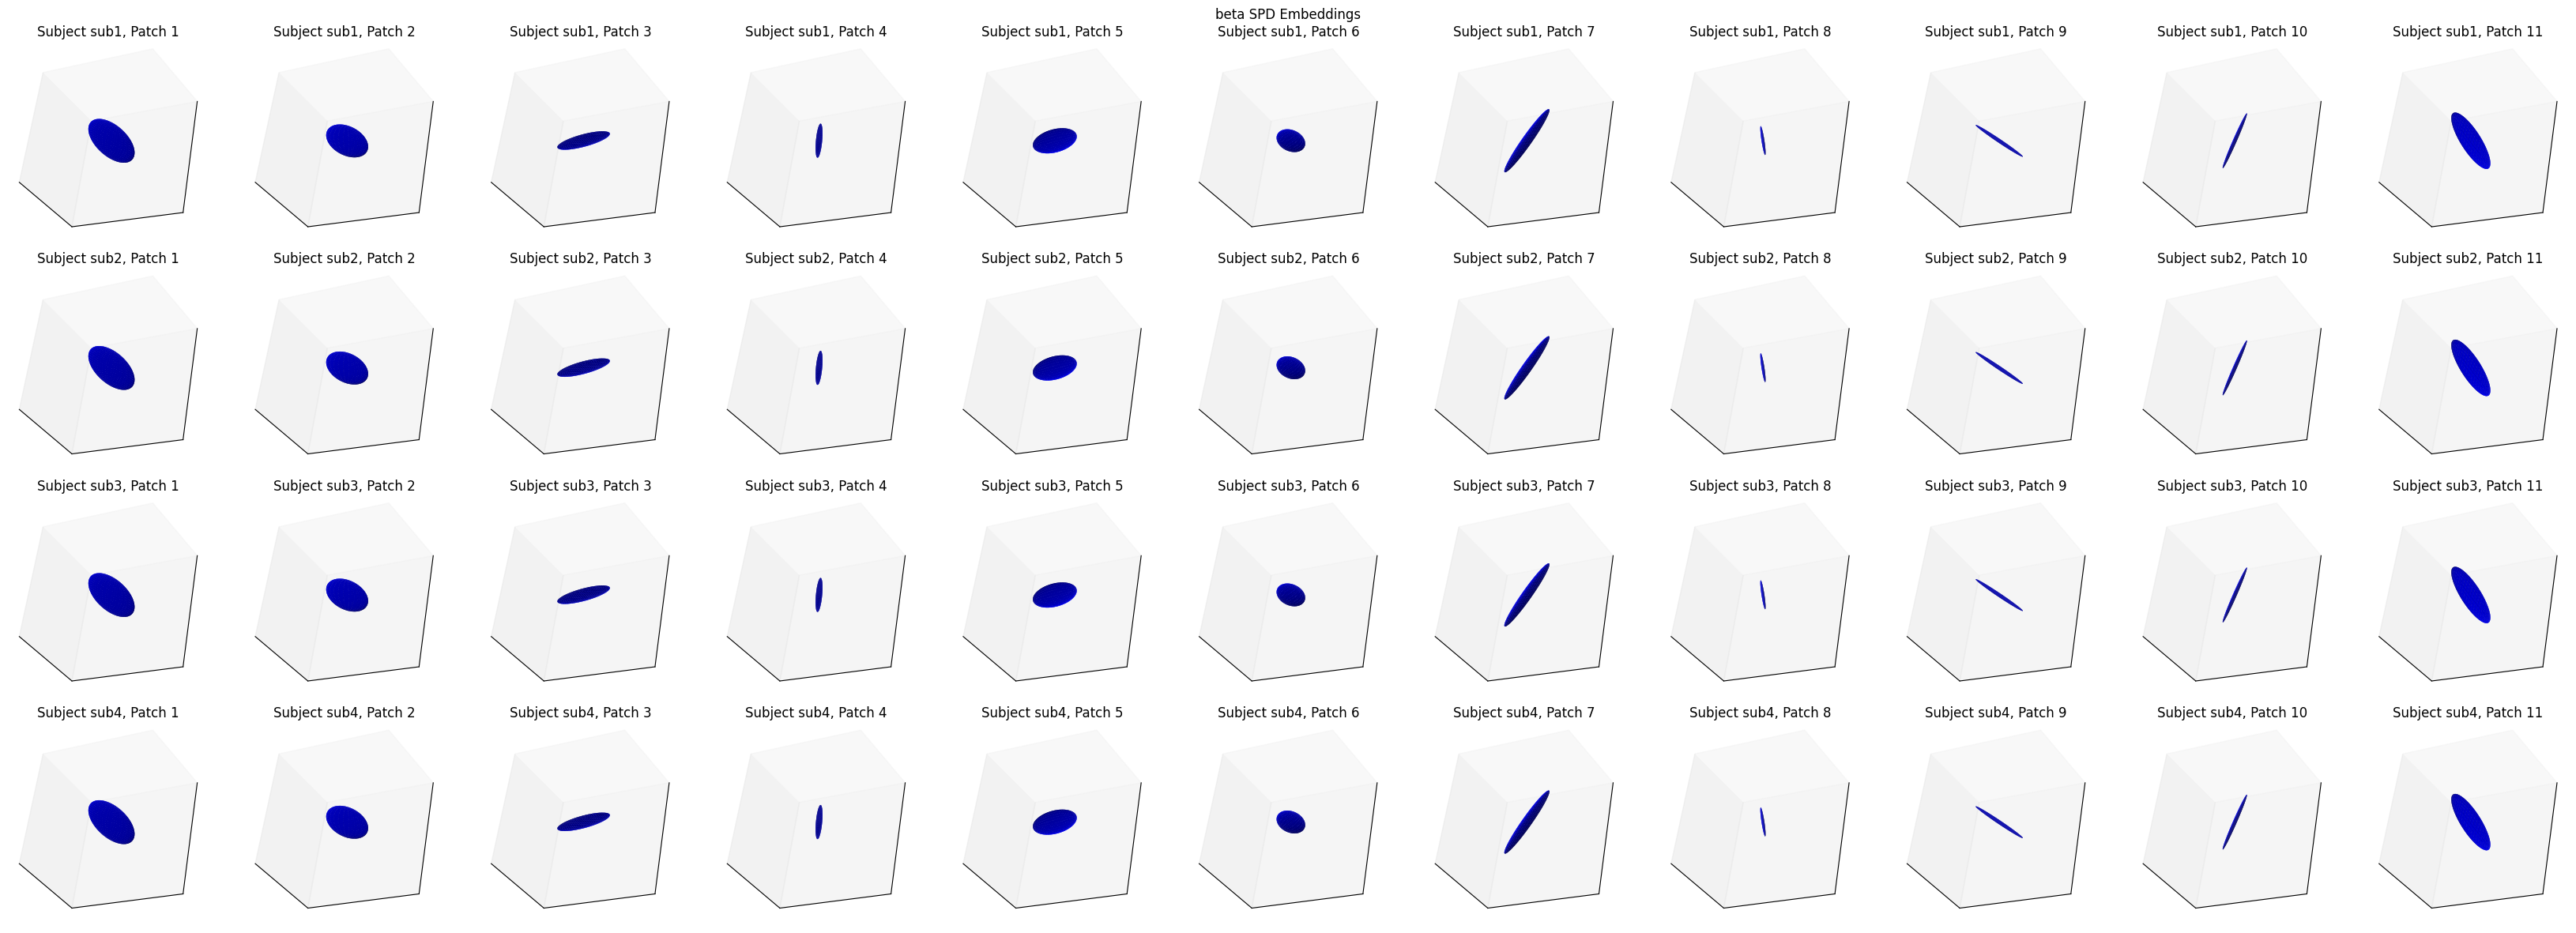

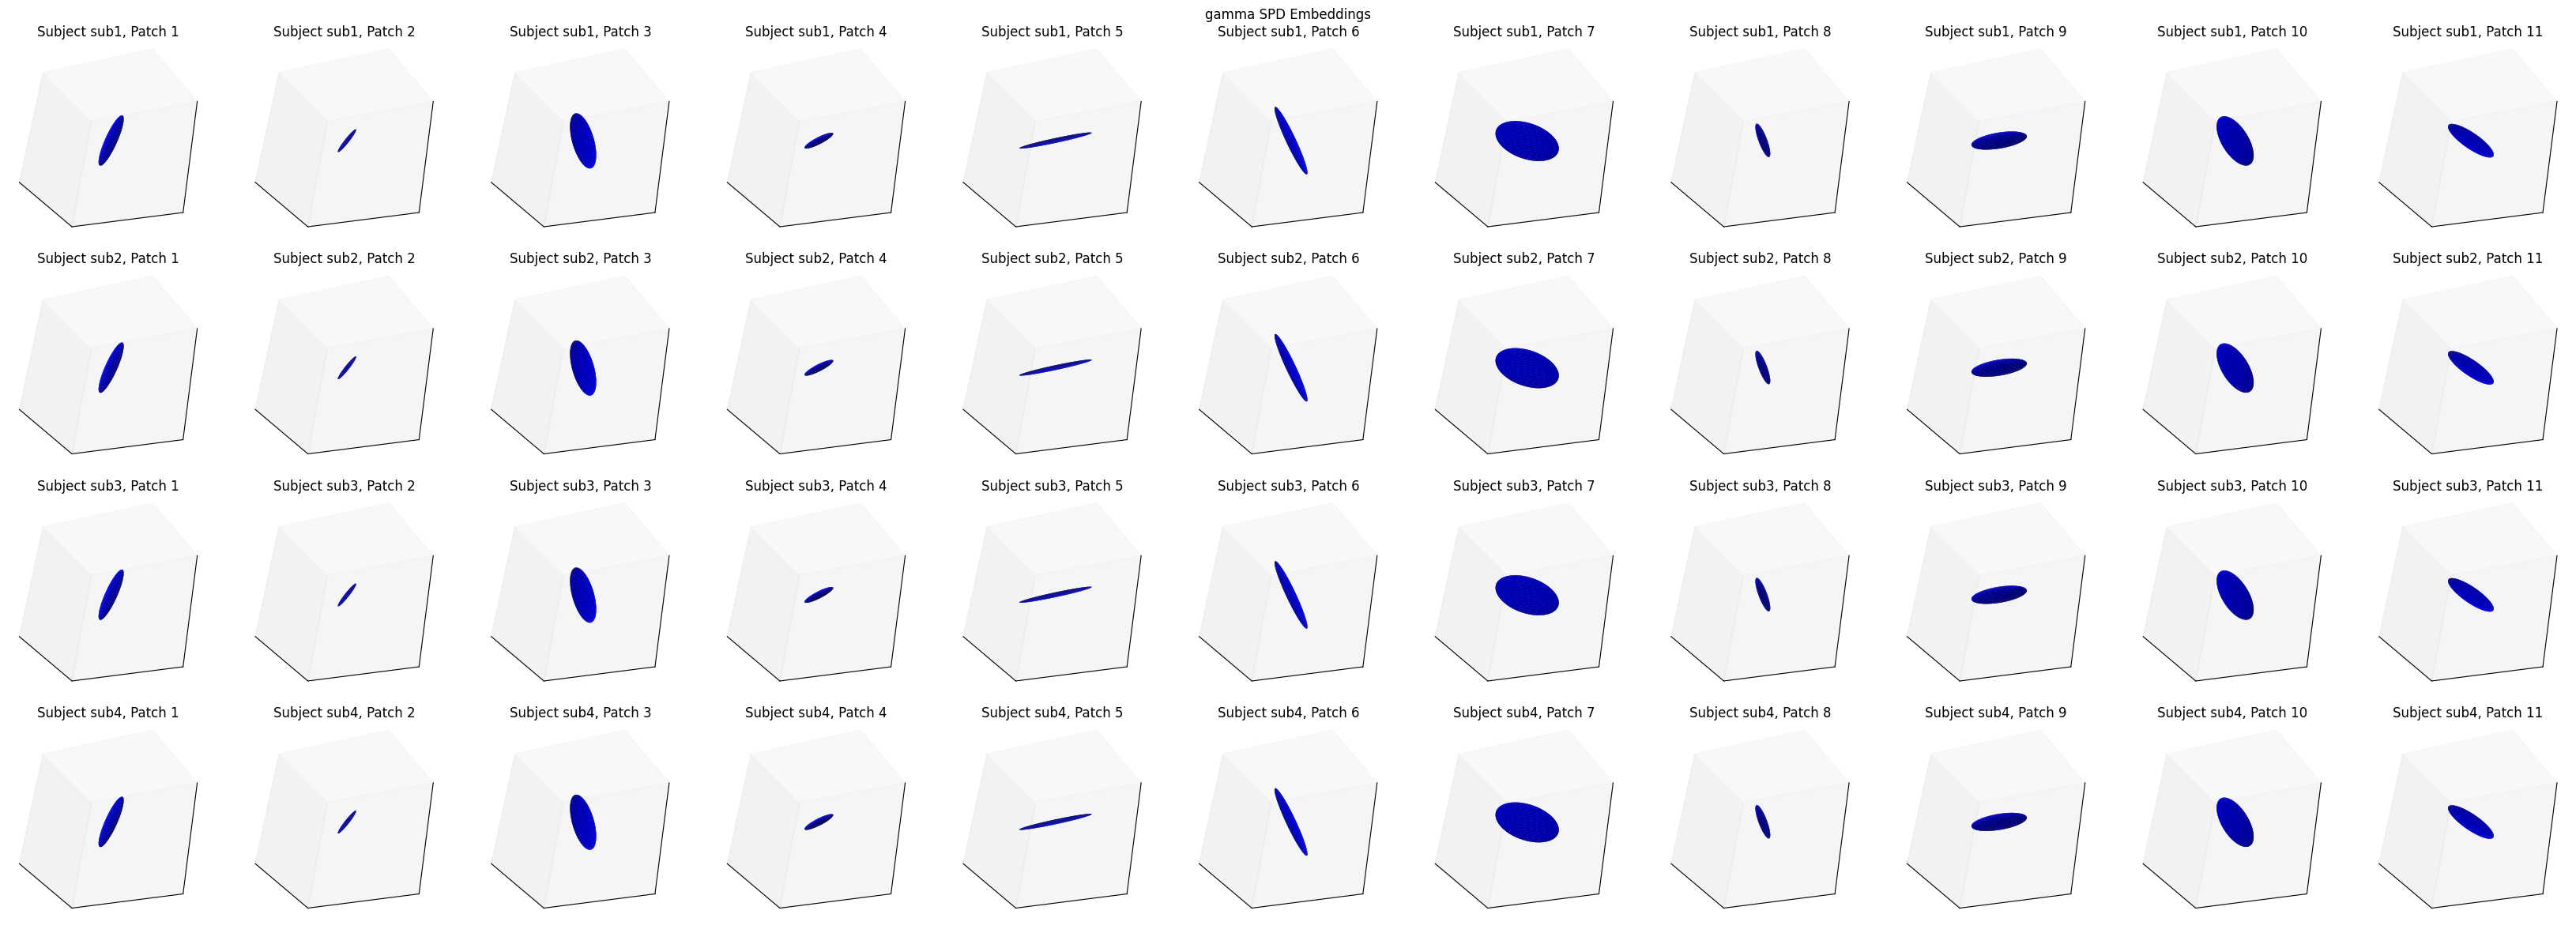

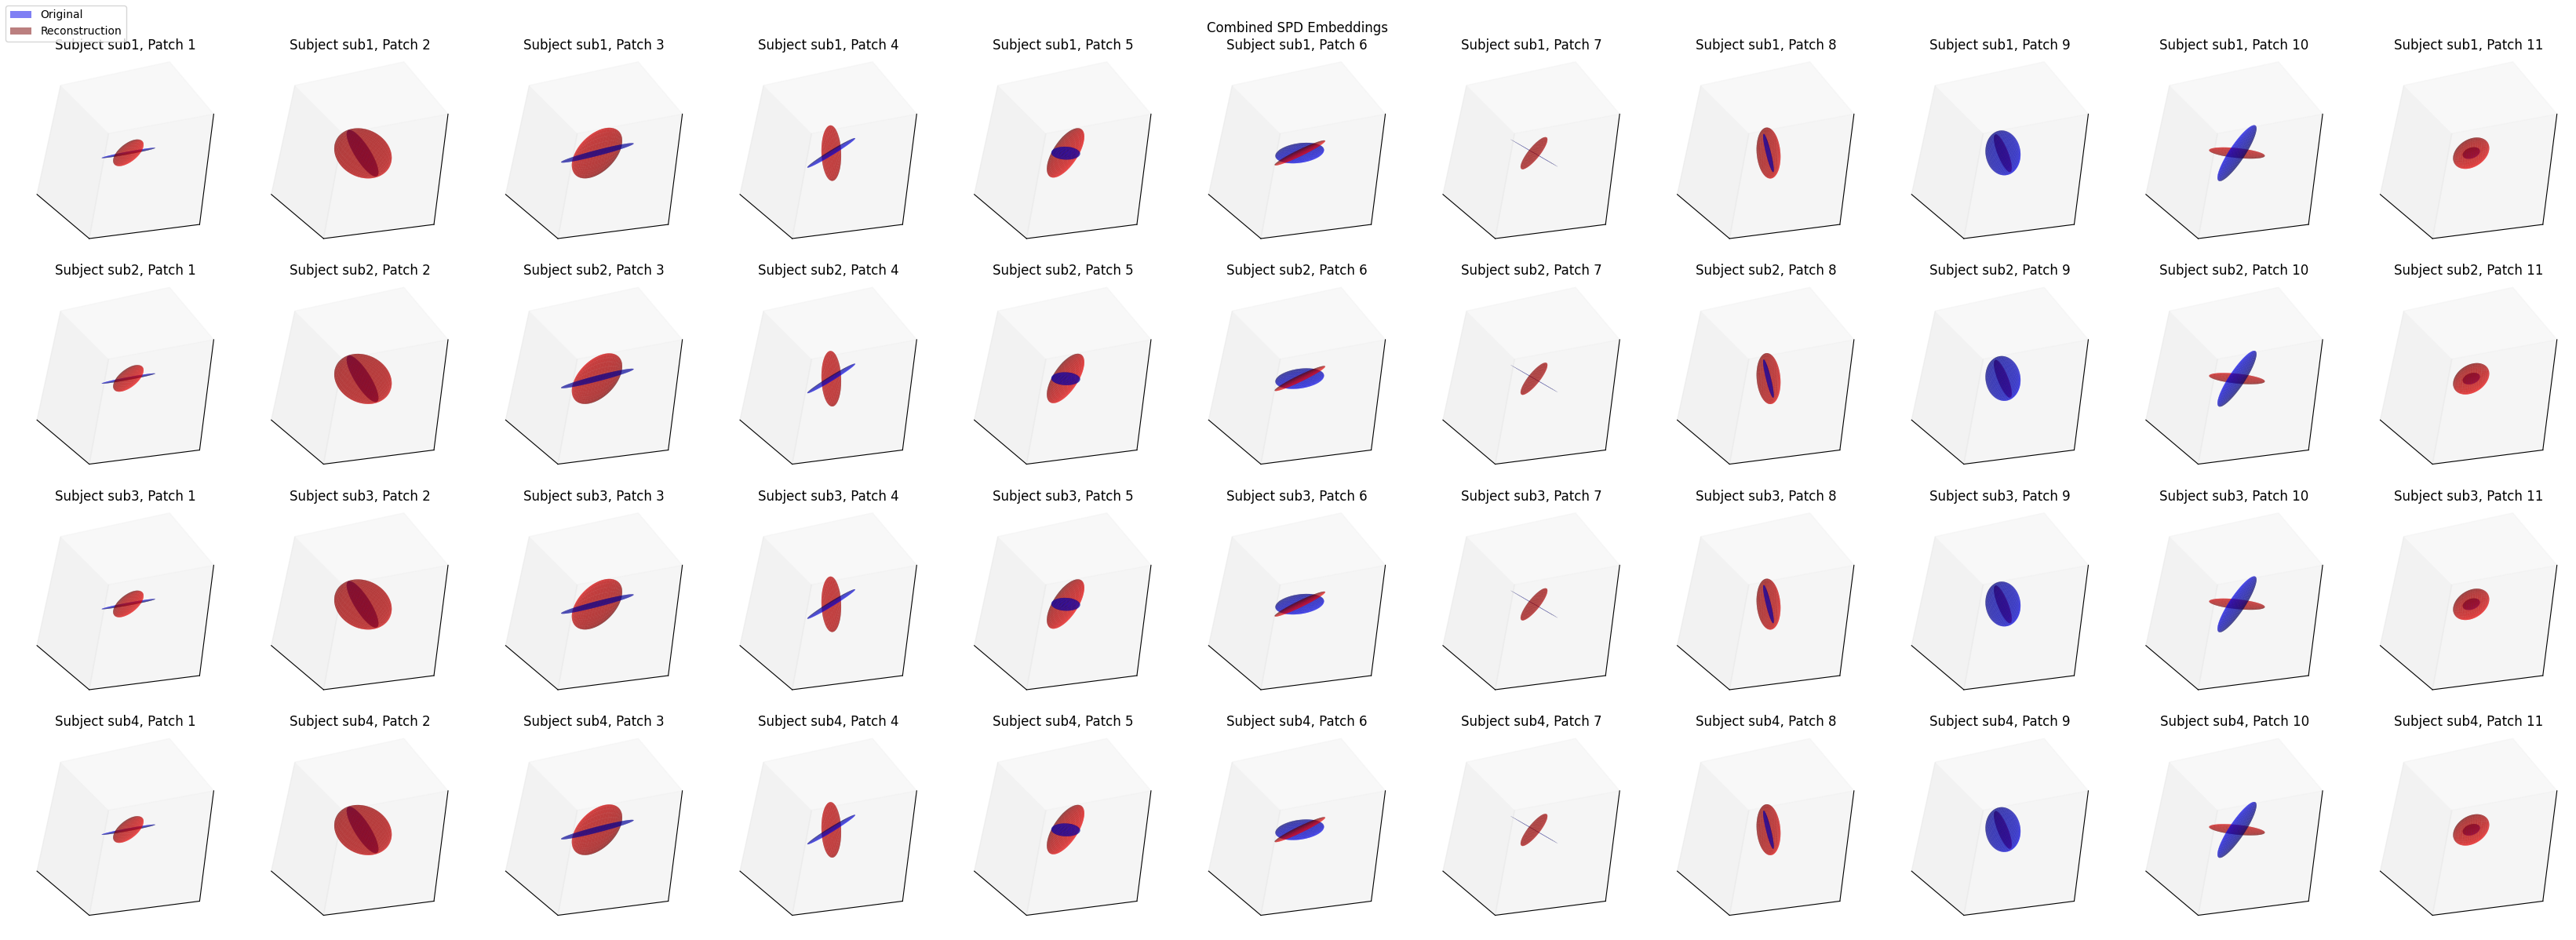

In [5]:
wavelet_figs, combined_fig = plotSPDEmbedding(wavelet_manifold_output, combined_manifold_output, combined_manifold_output_masked, subject_names, num_patches=11, num_rows=4, num_cols=11)

for band, wavelet_fig in wavelet_figs.items():
    wavelet_fig.savefig(f"./test_figures/{band}_wavelet_fig.png")

combined_fig.savefig(f"./test_figures/combined_fig.png")
plt.show()